<a href="https://colab.research.google.com/github/crpinillag/ejercicios-ia-2026/blob/main/T2_simulacion_automata_celular_epidemiologico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 100.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.


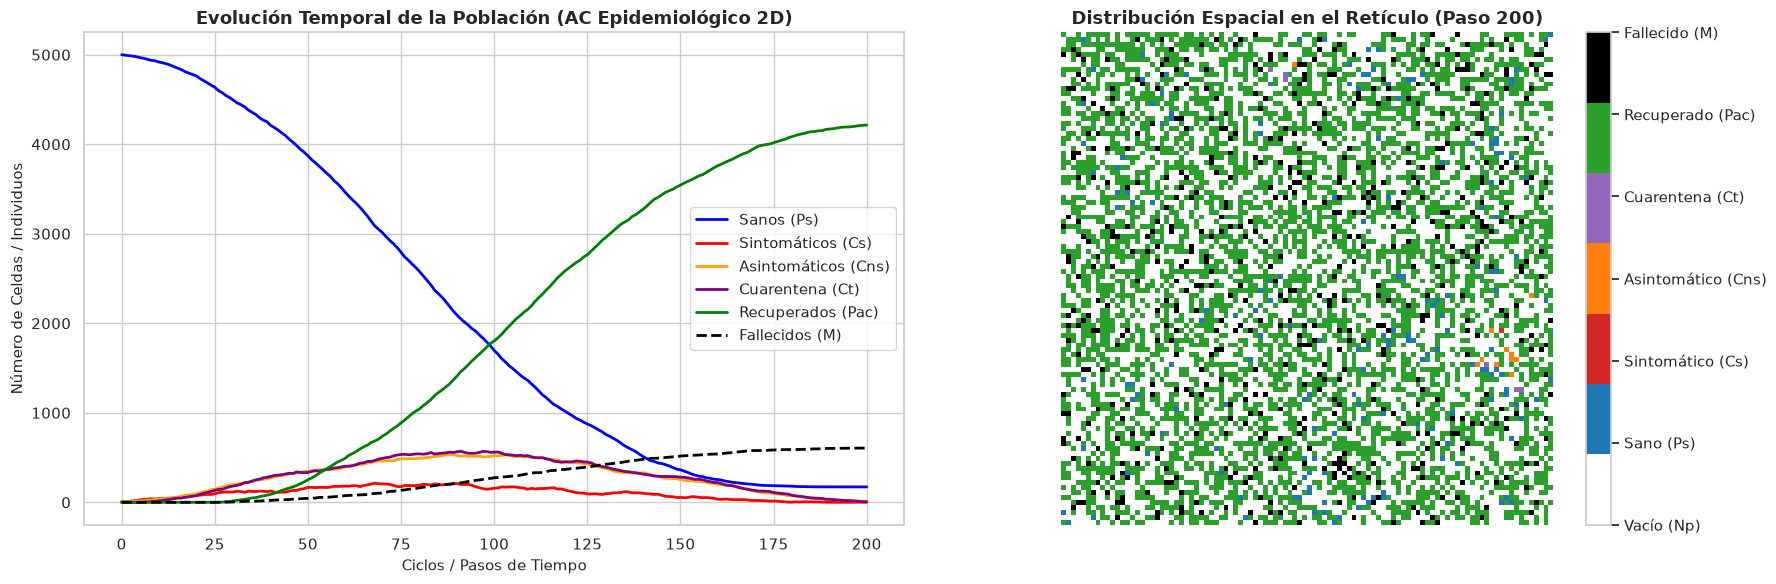

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Configuración de semilla para garantizar reproducibilidad
np.random.seed(42)

# ==========================================
# 1. DEFINICIÓN DE ESTADOS Y CONSTANTES
# ==========================================
NP = 0   # Celda vacía (No hay nada)
PS = 1   # Persona sana (Susceptible)
CS = 2   # Persona con síntomas (Infectado sintomático)
CNS = 3  # Persona asintomática (Infectado asintomático)
CT = 4   # Persona en cuarentena / atención médica
PAC = 5  # Persona recuperada con anticuerpos
M = 6    # Persona fallecida (retirada de la dinámica espacial)

# Parámetros del retículo y simulación
GRID_SIZE = 100
TOTAL_CELLS = GRID_SIZE * GRID_SIZE
TIMESTEPS = 200

# ==========================================
# 2. INICIALIZACIÓN DEL RETÍCULO
# ==========================================
grid = np.full((GRID_SIZE, GRID_SIZE), NP, dtype=int)
timer = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

# Selección de posiciones aleatorias únicas para la población inicial
all_indices = np.random.choice(TOTAL_CELLS, size=5010, replace=False)
ps_indices = all_indices[:5000]
cs_indices = all_indices[5000:5005]
cns_indices = all_indices[5005:5010]

grid.flat[ps_indices] = PS
grid.flat[cs_indices] = CS
grid.flat[cns_indices] = CNS

initial_grid = grid.copy()

# Estruturas para registro histórico de la población
history = {PS: [], CS: [], CNS: [], CT: [], PAC: [], M: [], NP: []}

# Desplazamientos para la vecindad de Moore (8 vecinos)
moore_offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
# Desplazamientos para movimiento físico (Norte, Sur, Este, Oeste)
cardinal_directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

# ==========================================
# 3. BUCLE PRINCIPAL DE LA SIMULACIÓN
# ==========================================
for step in range(TIMESTEPS):
    # Registrar conteos actuales
    for state in [PS, CS, CNS, CT, PAC, M, NP]:
        history[state].append(np.sum(grid == state))

    new_grid = grid.copy()
    new_timer = timer.copy()

    # Matriz vectorizada para la vecindad de Moore de infectados (CS + CNS)
    infected_mask = (grid == CS) | (grid == CNS)
    infected_neighbors = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

    for dr, dc in moore_offsets:
        infected_neighbors += np.roll(np.roll(infected_mask, dr, axis=0), dc, axis=1)

    # --- A. REGLAS PROBABILÍSTICAS Y DE TRANSICIÓN ---
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            current_state = grid[r, c]

            # Persona Sana (PS) -> Infección probabilística
            if current_state == PS:
                n = infected_neighbors[r, c]
                if n > 0:
                    prob_contagion = min(0.1 * n, 1.0)
                    if np.random.rand() < prob_contagion:
                        # Distribución: 40% Asintomático (CNS), 60% Sintomático (CS)
                        if np.random.rand() < 0.4:
                            new_grid[r, c] = CNS
                        else:
                            new_grid[r, c] = CS
                        new_timer[r, c] = 0

            # Sintomático (CS) -> Transición a Cuarentena (CT) tras 7 ciclos
            elif current_state == CS:
                new_timer[r, c] += 1
                if new_timer[r, c] >= 7:
                    new_grid[r, c] = CT
                    new_timer[r, c] = 0

            # Asintomático (CNS) -> Transición a Recuperado (PAC) tras 30 ciclos
            elif current_state == CNS:
                new_timer[r, c] += 1
                if new_timer[r, c] >= 30:
                    new_grid[r, c] = PAC
                    new_timer[r, c] = 0

            # En Cuarentena (CT) -> Transición tras 20 ciclos (80% PAC, 20% Fallecido M)
            elif current_state == CT:
                new_timer[r, c] += 1
                if new_timer[r, c] >= 20:
                    if np.random.rand() < 0.8:
                        new_grid[r, c] = PAC
                    else:
                        new_grid[r, c] = M
                    new_timer[r, c] = 0

    # --- B. DESPLAZAMIENTO ESTOCÁSTICO A CELDAS VACÍAS (N, S, E, O) ---
    mobile_mask = (new_grid == PS) | (new_grid == CS) | (new_grid == CNS) | (new_grid == PAC)
    mobile_coords = np.argwhere(mobile_mask)
    np.random.shuffle(mobile_coords)

    for r, c in mobile_coords:
        if new_grid[r, c] != NP and np.random.rand() < 0.25:
            dr, dc = cardinal_directions[np.random.randint(0, 4)]
            nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE

            # Movimiento solo a celda vacía
            if new_grid[nr, nc] == NP:
                new_grid[nr, nc] = new_grid[r, c]
                new_timer[nr, nc] = new_timer[r, c]
                new_grid[r, c] = NP
                new_timer[r, c] = 0

    grid = new_grid
    timer = new_timer

# Registrar último paso de tiempo
for state in [PS, CS, CNS, CT, PAC, M, NP]:
    history[state].append(np.sum(grid == state))

# ==========================================
# 4. GENERACIÓN DE RESULTADOS VISUALES
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Evolución Temporal (Curva de Estados Epidemiológicos)
time_axis = np.arange(len(history[PS]))
axes[0].plot(time_axis, history[PS], label='Sanos (Ps)', color='blue', linewidth=2)
axes[0].plot(time_axis, history[CS], label='Sintomáticos (Cs)', color='red', linewidth=2)
axes[0].plot(time_axis, history[CNS], label='Asintomáticos (Cns)', color='orange', linewidth=2)
axes[0].plot(time_axis, history[CT], label='Cuarentena (Ct)', color='purple', linewidth=2)
axes[0].plot(time_axis, history[PAC], label='Recuperados (Pac)', color='green', linewidth=2)
axes[0].plot(time_axis, history[M], label='Fallecidos (M)', color='black', linestyle='--', linewidth=2)

axes[0].set_title("Evolución Temporal de la Población (AC Epidemiológico 2D)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Ciclos / Pasos de Tiempo", fontsize=11)
axes[0].set_ylabel("Número de Celdas / Individuos", fontsize=11)
axes[0].legend(loc='right')

# Gráfico 2: Distribución Espacial del Retículo al Final de la Simulación
colors = ["#ffffff", "#1f77b4", "#d62728", "#ff7f0e", "#9467bd", "#2ca02c", "#000000"]
cmap = ListedColormap(colors)
im = axes[1].imshow(grid, cmap=cmap, vmin=0, vmax=6)
axes[1].set_title("Distribución Espacial en el Retículo (Paso 200)", fontsize=13, fontweight='bold')
axes[1].axis('off')

# Barra de colores con etiquetas de estado
cbar = fig.colorbar(im, ax=axes[1], ticks=range(7), fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(['Vacío (Np)', 'Sano (Ps)', 'Sintomático (Cs)', 'Asintomático (Cns)', 'Cuarentena (Ct)', 'Recuperado (Pac)', 'Fallecido (M)'])

plt.tight_layout()
plt.show()

# Explicación Algorítmica y Análisis Epidemiológico
## Lógica de la Matriz de Transición Probabilística
1. Detección Local y Ratio de Infección
  ($P_{contagio} = 0.n$):Cada celda susceptible ($P_s$) analiza sus 8 vecinos en la vecindad de Moore. Si detecta $n$ vecinos infectados activos ($C_s$ o $C_{ns}$), la probabilidad de contagio se escala proporcionalmente a $0.1 \times n$. Si ocurre el contagio, el individuo migra al estado asintomático ($C_{ns}$) con probabilidad $0.4$ o a sintomático ($C_s$) con probabilidad $0.6$.

2. Dinámica Temporal y Estado Crítico:
    * Infectados Sintomáticos ($C_s$): Permanecen 7 ciclos contagiando localmente antes de aislarse en cuarentena/atención médica ($C_t$).
    * Infectados Asintomáticos ($C_{ns}$): Permanecen 30 ciclos en movimiento y difusión antes de recuperarse ($P_{ac}$).
    * Cuarentena ($C_t$): Tras 20 ciclos de aislamiento, el $80\%$ pasa a recuperados con inmunidad ($P_{ac}$) y el $20\%$ fallece ($M$).

3. Desplazamiento Estocástico Anisotrópico: En cada ciclo, las celdas móviles ($P_s, C_s, C_{ns}, P_{ac}$) intentan desplazarse con una probabilidad $P=0.25$ hacia una posición ortogonal contigua (Norte, Sur, Este u Oeste). El movimiento solo se concreta si la celda destino está vacía ($N_p$), simulando la deriva física y el distanciamiento espacial.

## Análisis de Resultados y EstabilizaciónPico Epidemiológico y Saturación:
  Durante los primeros 40–80 ciclos se observa la fase de aceleración exponencial del brote impulsada por la alta movilidad de los asintomáticos ($C_{ns}$). Fase de Estabilización: Entre los ciclos 120 y 180 el sistema converge hacia una meseta de inmunidad de rebaño o agotamiento de susceptibles ($P_s$). La curva de fallecidos ($M$) y recuperados ($P_{ac}$) se estabiliza de manera asintótica cuando el número de infectados activos tiende a cero.